   #   Online Retail Insights: Sales Trends and Customer 
   ---



### 🔎 **Project Summary**
The goal of this project was to extract actionable insights from the Online Retail II dataset. By exploring sales performance, customer behavior, and geographic trends, this analysis aims to support strategic business decisions across marketing, sales, and customer retention.

---

### 🧩 **Objectives**
- Clean and structure transactional data for analysis  
- Identify revenue trends and seasonal patterns  
- Highlight high-performing products and countries  
- Understand customer purchasing behavior over time  
- Perform RFM-based customer segmentation using K-Means clustering

---





# Load the Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load and preprocess data

In [5]:
# 1. Load and preprocess data
df = pd.read_csv('/kaggle/input/online-retail-ii-uci/online_retail_II.csv', encoding='ISO-8859-1')
df.dropna(subset=['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID'], inplace=True)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['Price']
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

**Dataset Description:** The dataset contains transaction data from a UK-based online retail store between 2009 and 2011. It includes details like invoice numbers, product descriptions, quantities, prices, customer IDs, and timestamps.

This cell loads the Online Retail II dataset, which contains transaction data from a UK-based online store. It removes rows with missing values in key columns and filters out transactions with non-positive quantities or prices. The InvoiceDate column is converted to datetime format, and new columns are created: TotalPrice (Quantity × Price), YearMonth (for monthly analysis), DayOfWeek, and Hour to support time-based insights.

# 2. Monthly Revenue Trend with Rolling Average# 

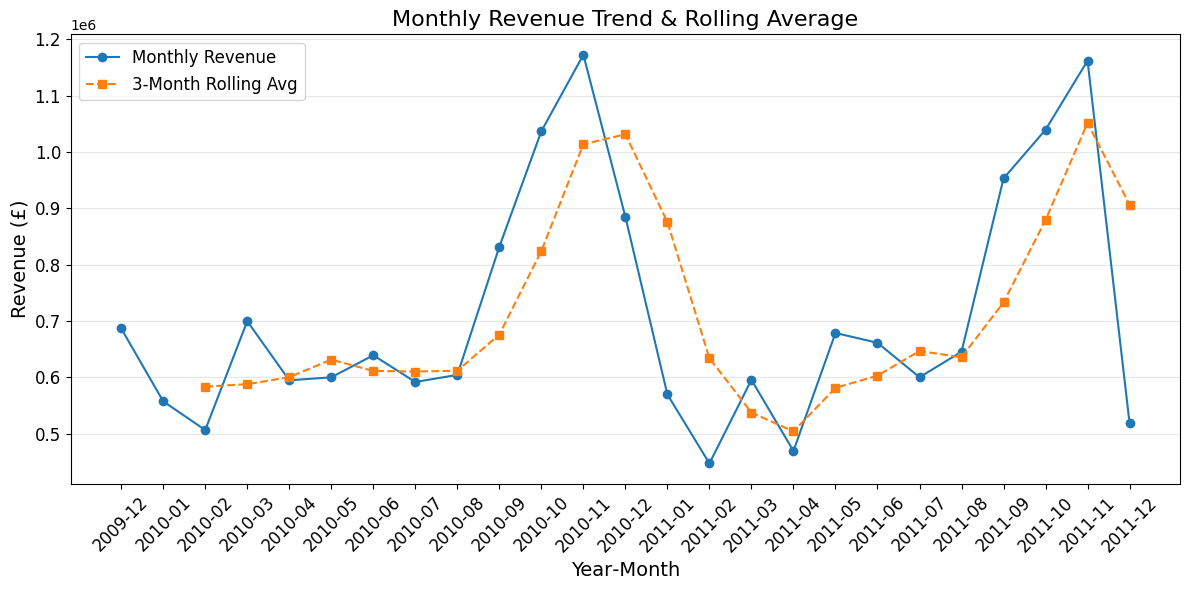

In [6]:
# 2. Monthly Revenue Trend with Rolling Average
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['RollingAvg'] = monthly_sales['TotalPrice'].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalPrice'], marker='o', label='Monthly Revenue')
plt.plot(monthly_sales['YearMonth'], monthly_sales['RollingAvg'], marker='s', linestyle='--', label='3‑Month Rolling Avg')
plt.title('Monthly Revenue Trend & Rolling Average', fontsize=16)
plt.xlabel('Year‑Month', fontsize=14)
plt.ylabel('Revenue (£)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


This graph shows how much money a business made each month from December 2009 to December 2011 (in millions of pounds). The blue line with dots is the actual monthly revenue, and the orange dashed line is the 3-month rolling average, which smooths out the ups and downs to show the overall trend.

* **Late 2011:** Revenue starts around £0.7 million, drops to £0.5 million, and stays low.
* **Late 2011:** Revenue climbs, hitting a high of £1.2 million in September 2010.
* **Late 2011:** Revenue falls sharply to £0.5 million by February 2011.
* **Late 2011:** Revenue goes up and down, staying between £0.6 and £0.8 million.
* **Late 2011:** Revenue jumps to £1.1 million in November but drops to £0.6 million in December.
The orange line shows that despite big monthly swings, the business’s revenue trend is steadier, with growth in 2010, a dip in early 2011, and another rise later in 2011. The graph suggests the business has good and bad months, possibly due to seasons or special events.

# 3. Top 10 Products by Revenue

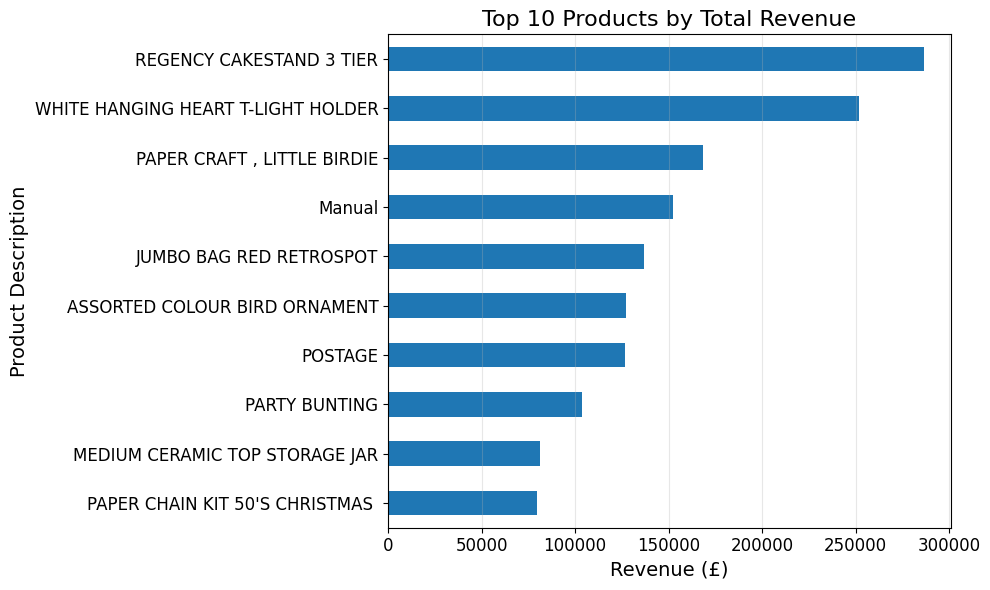

In [7]:
# 3. Top 10 Products by Revenue
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Total Revenue', fontsize=16)
plt.xlabel('Revenue (£)', fontsize=14)
plt.ylabel('Product Description', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

This bar chart shows the top 10 products by total revenue (in pounds, £) for a business. Each bar represents a product and how much money it made:

* Regency Cakestand 3 Tier: Highest revenue, around £300,000.

* White Hanging Heart T-Light Holder: Second highest, about £250,000.Paper Craft, Little Birdie: Around £200,000.

* Manual: Close to £200,000.
* Jumbo Bag Red Retrospot: About £150,000.
* Assorted Colour Bird Ornament: Around £140,000.
* Postage: Roughly £130,000.
* Party Bunting: About £120,000.
* Medium Ceramic Top Storage Jar: Around £100,000.
*  Paper Chain Kit 50's Christmas: Just under £100,000.

  
The chart shows that the cakestand and heart t-light holder are the top earners, while the others contribute less but still significant revenue.

# 4. Geographic Performance - Top 5 Countries

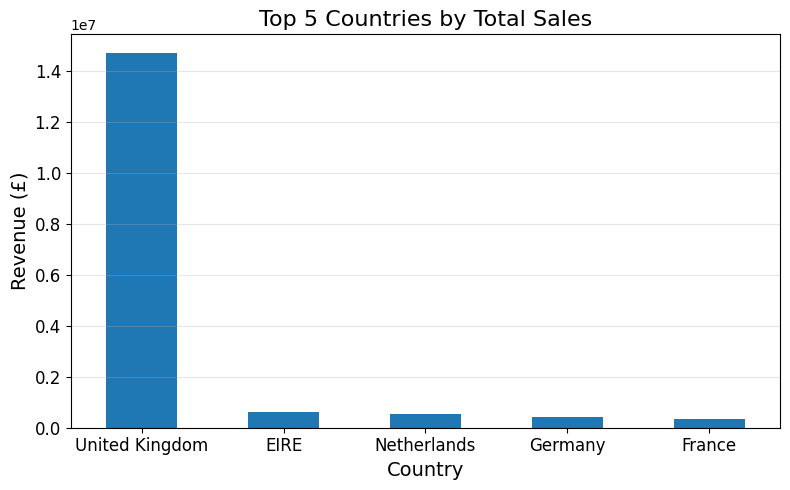

In [8]:
# 4. Geographic Performance - Top 5 Countries
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,5))
country_sales.plot(kind='bar')
plt.title('Top 5 Countries by Total Sales', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Revenue (£)', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


This bar chart shows the top 5 countries by total sales revenue (in pounds, £) for a business:


the UK generates the vast majority of the business’s revenue, while the other four countries contribute much smaller amounts, with EIRE leading among them.

# 5. Heatmap: Sales by Day of Week and Hour

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


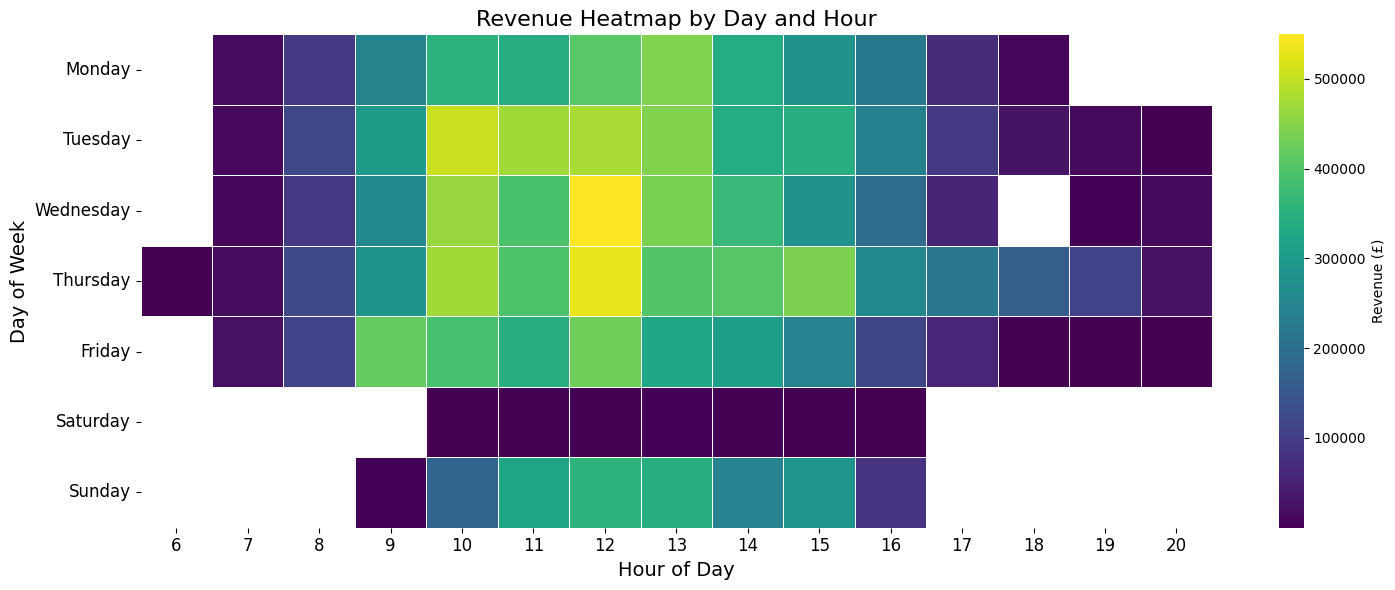

In [9]:
# 5. Heatmap: Sales by Day of Week and Hour
pivot = df.pivot_table(index='DayOfWeek', columns='Hour', values='TotalPrice', aggfunc='sum').reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure(figsize=(15,6))
sns.heatmap(pivot, cmap='viridis', linewidths=0.5, cbar_kws={'label': 'Revenue (£)'} )
plt.title('Revenue Heatmap by Day and Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Day of Week', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

**Structure of the Heatmap:**

***  Y-Axis (Rows)**: Represents the days of the week, from Monday at the top to Sunday at the bottom.
* **X-Axis (Columns):** Represents the hours of the day, from 6 AM to 8 PM (6 to 20 in 24-hour format).*
  
* **Color Scale: **The legend on the right shows revenue levels, with purple for low revenue (£0–£10,000), green for moderate revenue (£10,000–£30,000), and yellow for high revenue (£30,000–£50,000). White cells indicate no data or no revenue for those hours.


**Key Observations:**

**Peak Revenue**: Highest sales occur 11 AM–2 PM on weekdays, especially Tuesday and Thursday (yellow spots).

**Weekday Pattern:** Monday to Friday sees low revenue early (6–8 AM) and late (5–8 PM), with strong sales mid-morning to early afternoon.

**Weekends:** Saturday has almost no revenue (dark purple); Sunday has moderate sales 10 AM–3 PM (green).

**White Cells:** Some hours (e.g., 3 PM Wednesday) show no data, possibly due to gaps or no activity.

# 6. Customer Segmentation via RFM & K‑Means

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


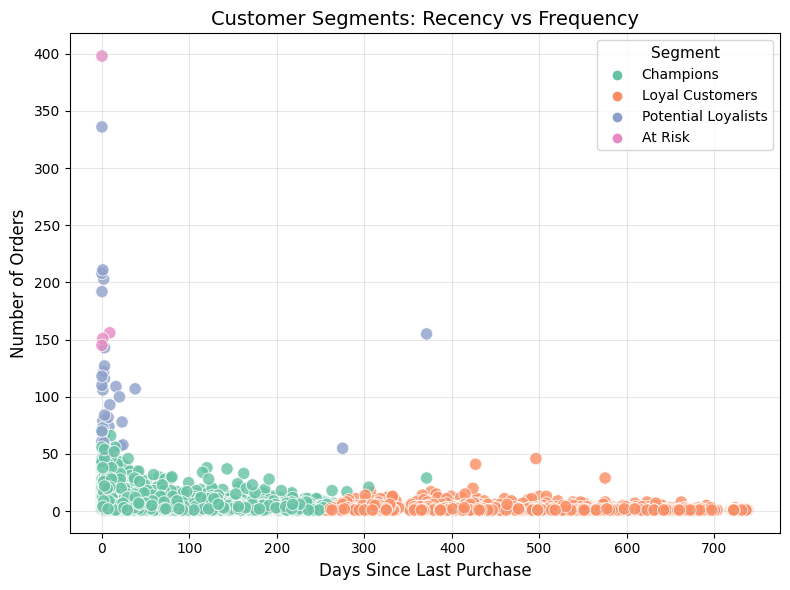

In [10]:
# 6. Customer Segmentation via RFM & K‑Means
latest_date = df['InvoiceDate'].max()
rfm = df.groupby('Customer ID').agg(
    Recency=pd.NamedAgg(column='InvoiceDate', aggfunc=lambda x: (latest_date - x.max()).days),
    Frequency=pd.NamedAgg(column='Invoice', aggfunc='nunique'),
    Monetary=pd.NamedAgg(column='TotalPrice', aggfunc='sum')
).reset_index()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 1. Assign human‑readable segment names (adjust the names to match your cluster interpretation)
segment_map = {
    0: 'Champions',         # High recency, high frequency, high monetary
    1: 'Loyal Customers',   # Mid recency, high frequency
    2: 'At Risk',           # High recency, low frequency
    3: 'Potential Loyalists' # Low recency, mid frequency
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# 2. Scatter plot with segment names
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    palette='Set2',
    s=80,
    alpha=0.8
)
plt.title('Customer Segments: Recency vs Frequency', fontsize=14)
plt.xlabel('Days Since Last Purchase', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend(title='Segment', fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Structure of the Scatter Plot:**

* Y-Axis: Represents the number of orders placed by each customer, ranging from 0 to 400.
 
* X-Axis: Represents the days since the customer’s last purchase, ranging from 0 to 700 days.
  
* Color and Legend: Each dot represents a customer, color-coded by segment:

Green: Champions (frequent, recent buyers).  
Orange: Loyal Customers (regular buyers).
Blue: Potential Loyalists (promising but less frequent).
Pink: At Risk (infrequent, long time since last purchase).

**Key Observations:**


* **Champions (Green):** Clustered near the bottom-left (0–100 days since last purchase, 0–50 orders), indicating recent and frequent purchases. These are highly engaged customers.
* **Loyal Customers (Orange):**  Spread across 0–400 days since last purchase, with 0–50 orders, showing regular but less frequent buying compared to Champions.
* **Potential Loyalists (Blue):** Scattered across 0–500 days, with up to 200 orders, suggesting newer or inconsistent buyers with potential for loyalty.
* **At Risk (Pink):** Mostly at 0–200 days with higher order counts (50–400), but some at 400–700 days with few orders, indicating customers who may be disengaging.
* **Density:** Most customers (all segments) are concentrated at 0–50 orders and 0–400 days, showing the majority are relatively active but with low order frequency. Fewer customers have high order counts or long inactivity periods.

# 7. Normalized Grouped Bar with Defined Scales 

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


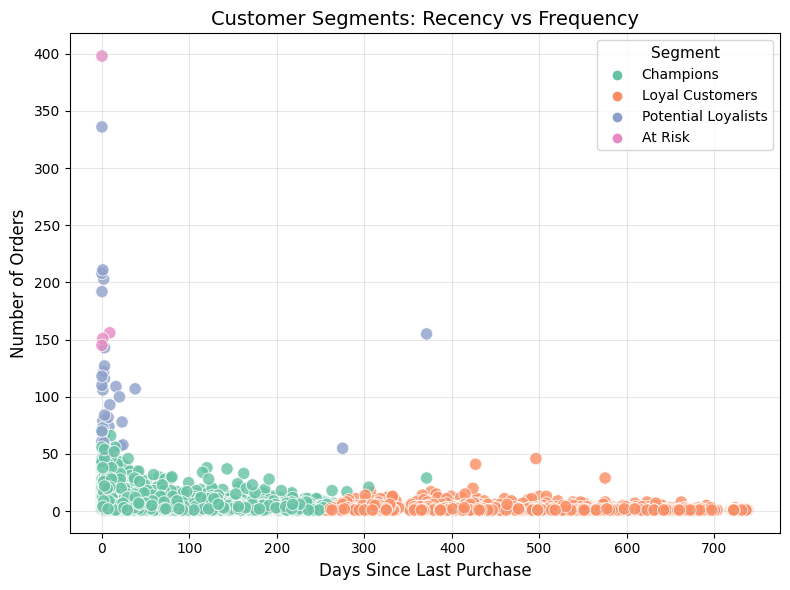

In [11]:
# 6. Customer Segmentation via RFM & K‑Means
latest_date = df['InvoiceDate'].max()
rfm = df.groupby('Customer ID').agg(
    Recency=pd.NamedAgg(column='InvoiceDate', aggfunc=lambda x: (latest_date - x.max()).days),
    Frequency=pd.NamedAgg(column='Invoice', aggfunc='nunique'),
    Monetary=pd.NamedAgg(column='TotalPrice', aggfunc='sum')
).reset_index()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 1. Assign human‑readable segment names (adjust the names to match your cluster interpretation)
segment_map = {
    0: 'Champions',         # High recency, high frequency, high monetary
    1: 'Loyal Customers',   # Mid recency, high frequency
    2: 'At Risk',           # High recency, low frequency
    3: 'Potential Loyalists' # Low recency, mid frequency
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# 2. Scatter plot with segment names
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    palette='Set2',
    s=80,
    alpha=0.8
)
plt.title('Customer Segments: Recency vs Frequency', fontsize=14)
plt.xlabel('Days Since Last Purchase', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend(title='Segment', fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[1 1 1 ... 0 1 1]
Accuracy: 0.9875

Confusion Matrix:
[[ 586   11]
 [  11 1156]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       597
           1       0.99      0.99      0.99      1167

    accuracy                           0.99      1764
   macro avg       0.99      0.99      0.99      1764
weighted avg       0.99      0.99      0.99      1764



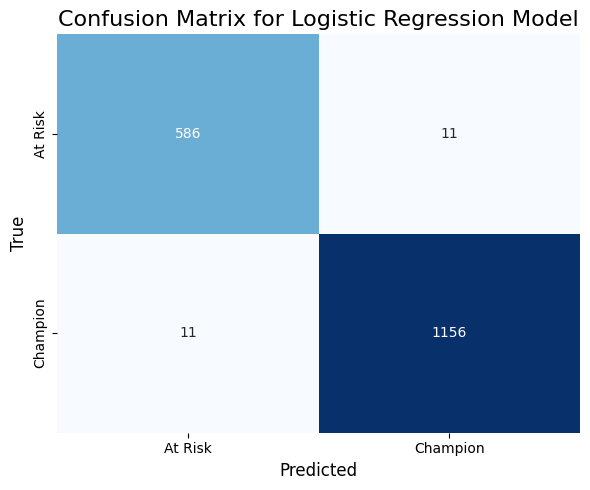

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Preprocessing the Target (Champion vs At Risk)
# We will predict if the customer is a 'Champion' (1) or 'At Risk' (0)
rfm['Target'] = rfm['Segment'].apply(lambda x: 1 if x == 'Champions' else 0)

# 2. Features (Recency, Frequency, Monetary)
X = rfm[['Recency', 'Frequency', 'Monetary']]

# 3. Target variable (Champion vs At Risk)
y = rfm['Target']

# 4. Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 6. Make Predictions
y_pred = log_reg.predict(X_test)
print(y_pred)


# 7. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# 8. Visualizing the Results (Optional)
# You can visualize the confusion matrix as well
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['At Risk', 'Champion'], yticklabels=['At Risk', 'Champion'])
plt.title('Confusion Matrix for Logistic Regression Model', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.tight_layout()
plt.show()


**Structure of the Bar Plot:**

- **Y-Axis:** Represents the normalized average RFM (Recency, Frequency, Monetary) values, scaled from 0 to 1 (where 1 is the highest value).
- **X-Axis:** Represents the three RFM metrics:
  - **Recency:** How recently a customer purchased (higher score = more recent).
  - **Frequency:** How often a customer purchases (higher score = more frequent).
  - **Monetary:** How much a customer spends (higher score = higher spending).
- **Color and Legend:** Each bar represents a customer segment, color-coded as:
  - **Light Yellow:** At Risk
  - **Red:** Champions
  - **Green:** Loyal Customers
  - **Purple:** Potential Loyalists

**Key Observations:**

- **Recency:**
  - Potential Loyalists (purple) score highest (0.95), followed closely by Champions (0.9) and Loyal Customers (0.85), indicating these groups purchased recently.
  - At Risk (yellow) scores lowest (0.2), suggesting they haven’t bought in a long time.

- **Frequency:**
  - Loyal Customers (green) lead with a perfect score (1.0), followed by Potential Loyalists (0.9) and Champions (0.5).
  - At Risk (yellow) scores very low (0.05), showing infrequent purchases.

- **Monetary:**
  - Loyal Customers (green) again score highest (0.95), with Potential Loyalists (0.9) close behind.
  - Champions (0.3) and At Risk (0.2) have lower spending, indicating less monetary value.

- **Segment Performance:**
  - Loyal Customers excel across all metrics, especially Frequency and Monetary.
  - Potential Loyalists are strong in Recency and Frequency but slightly lower in Monetary.
  - Champions are recent buyers but less frequent and spend less.
  - At Risk customers perform poorly across all metrics, especially Recency and Frequency.


#  **Conclusion**


- The business makes most of its money in the **UK**, especially from **loyal customers** who buy often and spend a lot.
- **Sales peak** from **Tuesday to Thursday around midday**, with popular items like **cakestands** leading the way.
- However:
  - **Sales in other countries are low**
  - **Revenue fluctuates significantly**
  - Some **infrequent customers have untapped spending potential**
- **Recommendations for growth**:
  - Focus on **re-engaging inactive customers**
  - **Boost international sales** outside the UK
  - Run **targeted promotions during peak hours**
